In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import smtplib
import os
import warnings

from matplotlib.patches import Ellipse
from email.message import EmailMessage
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv
from scipy.stats import weibull_min
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import r2_score



load_dotenv()
#get env variables
EMAIL_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")

## Starting Data

In [ ]:
def read_ons_csv(file_path) -> pd.DataFrame:
    """
    Read one ONS CSV file with common parsing rules.

        params:
            file_path: Path to the CSV file to be read
        returns:
            DataFrame with the content of the CSV file, with columns stripped and lowercased
    """
    file_path = Path(file_path)

    df = pd.read_csv(
        file_path,
        sep=";",
        encoding="utf-8",
        decimal=",",
        low_memory=False
    )

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

    return df

def parse_datetime_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Parse datetime columns from ONS datasets and ensure the column is datetime.
        
        params:
            df: DataFrame with a column named "din_instante" to be parsed as datetime
        returns:
            DataFrame with "din_instante" column parsed as datetime
    """
    df = df.copy()
    
    df["din_instante"] = pd.to_datetime(df["din_instante"], errors="coerce")

    return df

def concat_path_files(folder_path_name, report = False) -> pd.DataFrame:
    """
    Read all CSV files from a folder, parse them and concatenate into a single DataFrame.

        params:
            folder_path_name: Path to the folder containing the CSV files
            report: If True, prints the number of data lines lost during the concatenation process
        returns:
            DataFrame containing the concatenated data from all CSV files in the folder
    """

    folder_file_list = []
    count_file = 0
    df_files = []

    report_num = []

    folder_path = Path(folder_path_name)

    for item in folder_path.iterdir():
        count_file = count_file + 1
        if item.is_file():
            folder_file_list.append(item) 

    if len(folder_file_list) != count_file:
        return "Function could not read all files from folder"

    folder_files_list_sorted = sorted(folder_file_list)

    for item in folder_files_list_sorted:
        df_separated_file = read_ons_csv(item)
        report_num.append(df_separated_file.shape[0])
        df_files.append(parse_datetime_column(df_separated_file))

    df_concated = pd.concat(df_files, ignore_index=True)

    if report:
        print(f"The process lose {sum(report_num) - df_concated.shape[0]} data lines.")
    
    return df_concated

In [4]:
# Leitura dos dados salvos

path_dado_cof = "/Users/leonardocorreia/Projects PhD/projeto_cdv/dados_restricao_cof_SPEs"
path_dados_detail = "/Users/leonardocorreia/Projects PhD/projeto_cdv/dados_restrição_detalhamento_SPEs"

a = concat_path_files(path_dado_cof, report= True)
b = concat_path_files(path_dados_detail, report= True)

a_init = a.copy()
b_init = b.copy()

The process lose 0 data lines.
The process lose 0 data lines.


## Cleaning Data

In [ ]:
def validate_num_column_types(df: pd.DataFrame, numeric_columns: list[str]) -> pd.DataFrame:
    """
    Validate and cast dataframe column types.
    """

    df = df.copy()

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

def remove_duplicates(df: pd.DataFrame, subset: list[str]) -> tuple[pd.DataFrame, int]:

    initial_rows = len(df)

    df = df.drop_duplicates(subset=subset)

    removed_rows = initial_rows - len(df)

    return df, removed_rows


def remove_negative_generation_values(df: pd.DataFrame, numeric_columns: list[str]) -> tuple[pd.DataFrame, int]:

    initial_rows = len(df)

    mask = pd.Series(True, index=df.index)

    for col in numeric_columns:
        if col in df.columns:
            mask &= (
                df[col].isna() |
                (df[col] >= 0)
            )

    df = df[mask]

    removed_rows = initial_rows - len(df)

    return df, removed_rows


def remove_critical_nulls(df: pd.DataFrame, required_columns: list[str]) -> tuple[pd.DataFrame, int]:

    initial_rows = len(df)

    df = df.dropna(subset=required_columns)

    removed_rows = initial_rows - len(df)

    return df, removed_rows


def filter_invalid_wind_data(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:

    initial_rows = len(df)

    # Remove rows where the wind flag is not NaN and not 0 (assuming 0 means valid and 1 means invalid)

    df = df.dropna(subset=["ceg"])
    
    df = df[df["flg_dadoventoinvalido"] != 1]
    
    removed_rows = initial_rows - len(df)

    return df, removed_rows



def build_quality_report(df: pd.DataFrame) -> pd.DataFrame:

    report = pd.DataFrame({
        "column": df.columns,
        "null_count": df.isna().sum().values,
        "null_percentage": (
            df.isna().mean() * 100
        ).round(2).values,
        "dtype": df.dtypes.astype(str).values,
        "unique_values": df.nunique().values
    })

    return report.sort_values(
        by="null_percentage",
        ascending=False
    )


def build_quality_summary_text(
    dataset_name: str,
    initial_rows: int,
    removed_duplicates: int,
    removed_nulls: int,
    removed_negative_values: int,
    removed_invalid_wind: int,
    quality_report: pd.DataFrame
) -> str:
    """
    Build a textual data quality report.
    """

    total_removed = removed_duplicates + removed_nulls + removed_negative_values + removed_invalid_wind
    final_rows = initial_rows - total_removed
    removal_percentage = (total_removed / initial_rows) * 100 if initial_rows > 0 else 0

    top_null_columns = (
        quality_report
        .sort_values("null_percentage", ascending=False)
    )

    null_section = ""

    for _, row in top_null_columns.iterrows():
        null_section += (
            f"- {row['column']}: "
            f"{row['null_count']} nulls "
            f"({row['null_percentage']}%)\n"
        )

    report_text = f"""
        RELATÓRIO DE QUALIDADE DOS DADOS - {dataset_name}

        Data e hora de execução: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

        Responsável: Leonardo Correia

        1. CONTAGEM DE LINHAS
            Linhas iniciais: {initial_rows}
            Linhas finais: {final_rows}
            Total de linhas removidas: {total_removed}
            Percentual de remoção: {removal_percentage:.2f}%

        2. REGISTROS REMOVIDOS
            Duplicatas removidas: {removed_duplicates}
            Nulos críticos removidos: {removed_nulls}
            Valores numéricos negativos removidos: {removed_negative_values}
            Registros de vento inválidos removidos: {removed_invalid_wind}

        3. VALORES NULOS - TOP 10 COLUNAS
            {null_section}

        4. AVALIAÇÃO GERAL
        O conjunto de dados foi validado de acordo com o dicionário de dados do ONS.
        Valores nulos críticos foram removidos, valores nulos permitidos foram preservados,
        valores de geração negativa foram descartados e registros de vento inválidos foram filtrados.

        """

    return report_text


def send_quality_report_email(
    sender_email: str,
    sender_password: str,
    recipient_email: str,
    subject: str,
    body: str
) -> None:
    """
    Send the quality report by email.
    """

    message = EmailMessage()
    message["From"] = sender_email
    message["To"] = recipient_email
    message["Subject"] = subject
    message.set_content(body)

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as smtp:
        smtp.login(sender_email, sender_password)
        smtp.send_message(message)

In [ ]:
# Limpeza dos dados

numeric_columns = [
        "val_geracao",
        "val_geracaolimitada",
        "val_disponibilidade",
        "val_geracaoreferencia",
        "val_geracaoreferenciafinal"
    ]
####### dataset a
a = validate_num_column_types(a, numeric_columns=numeric_columns)

a, removed_negative_values = remove_negative_generation_values(a, numeric_columns=numeric_columns)

subset=["id_ons", "ceg", "din_instante"]
a, removed_duplicates = remove_duplicates(a, subset=subset)

required_columns = ["id_ons", "din_instante", "val_geracao"]
a, removed_nulls = remove_critical_nulls(a, required_columns=required_columns)

report_a = build_quality_summary_text(
    dataset_name="Restrição Detalhamento SPEs",
    initial_rows= a.shape[0],
    removed_duplicates=removed_duplicates,
    removed_nulls=removed_nulls,
    removed_negative_values=removed_negative_values,
    removed_invalid_wind=0,
    quality_report=build_quality_report(a)
)

###### dataset b
numeric_columns = ["val_ventoverificado", "val_geracaoestimada", "val_geracaoverificada", "flg_dadoventoinvalido"]

b = validate_num_column_types(b, numeric_columns=numeric_columns)

b, removed_negative_values = remove_negative_generation_values(b, numeric_columns=numeric_columns)

b, removed_invalid_wind = filter_invalid_wind_data(b)

subset=["id_ons", "ceg", "din_instante"]
b, removed_duplicates = remove_duplicates(b, subset=subset)

required_columns = ["id_ons", "din_instante", "val_ventoverificado", "val_geracaoestimada", "val_geracaoverificada"]
b, removed_nulls = remove_critical_nulls(b, required_columns=required_columns)

report_b = build_quality_summary_text(
    dataset_name="Restrição COFF SPEs",
    initial_rows= b.shape[0],
    removed_duplicates=removed_duplicates,
    removed_nulls=removed_nulls,
    removed_negative_values=0,
    removed_invalid_wind=removed_invalid_wind,
    quality_report=build_quality_report(b)
)


## Merging Data

A análise de tabelas relacionais costuma ser difícil principalmente quando elas são construídas com dados temporais. A partir disso, será criado uma série de Dataframes para extrair informações específicas dos dados. 

In [ ]:
def extract_ceg_core(ceg: str) -> str:
    """
    Extract the CEG core from full ONS CEG code.
    """
    if pd.isna(ceg):
        return None

    parts = str(ceg).split(".")

    if len(parts) >= 5:
        return parts[3]

    return str(ceg)


def load_spe_mapping(file_path: str) -> pd.DataFrame:
    """
    Load Casa dos Ventos SPE mapping file.
    """
    spe_df = pd.read_csv(file_path)

    spe_df["ceg_core"] = spe_df["ceg"].astype(str).str.strip()

    return spe_df


def filter_casa_dos_ventos_spes(
    detail_df: pd.DataFrame,
    spe_mapping_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Filter detail dataset to keep only Casa dos Ventos SPEs
    and add project/SPE metadata.
    """
    detail_df = detail_df.copy()

    detail_df["ceg_core"] = detail_df["ceg"].apply(extract_ceg_core)

    filtered_df = detail_df.merge(
        spe_mapping_df[["projeto", "spe", "ceg_core"]],
        on="ceg_core",
        how="inner"
    )

    return filtered_df


def aggregate_detail_by_project_hour(detail_cdv_df: pd.DataFrame, w_ceg = False) -> pd.DataFrame:
    """
    Aggregate SPE-level detail data into project-level time series.
    One row per project and timestamp.
    """
    df = detail_cdv_df.copy()

    numeric_columns_to_sum = [
        "val_geracao",
        "val_geracaoestimada",
        "val_geracaoverificada"
    ]

    numeric_columns_to_sum = [
        col for col in numeric_columns_to_sum
        if col in df.columns
    ]

    if w_ceg:
        numeric_columns_to_sum.append("val_ventoverificado")
        project_hour_df = (
            df.groupby(["projeto","ceg", "din_instante"], as_index=False)
            .agg(**{col: (col, "sum")for col in numeric_columns_to_sum},spe_count=("ceg_core", "nunique")
            )
        )
    else:
        project_hour_df = (
            df.groupby(["projeto", "din_instante"], as_index=False)
            .agg(**{col: (col, "sum")for col in numeric_columns_to_sum},spe_count=("ceg_core", "nunique")
            )
        )       

    return project_hour_df


def extract_project_from_cof_id(id_ons: str, project_list: list[str]) -> str:
    """
    Extract project name from COF id_ons using known project names.
    Example: CJU-BABBC -> BBC
    """
    if pd.isna(id_ons):
        return None

    id_ons = str(id_ons).upper()

    for project in project_list:
        project_upper = str(project).upper()

        if project_upper in id_ons:
            return project

    return None

In [ ]:
# Separando as SPEs da CdV a partir do documento spes_casa_dos_ventos.csv

spe_mapping_df = load_spe_mapping("/Users/leonardocorreia/Projects PhD/projeto_cdv/spes_casa_dos_ventos.csv")

detail_cdv_df = filter_casa_dos_ventos_spes(
    detail_df=b,
    spe_mapping_df=spe_mapping_df
)

detail_cdv_agg_df_per_proj = aggregate_detail_by_project_hour(detail_cdv_df, w_ceg = False)

detail_cdv_agg_df_per_ceg = aggregate_detail_by_project_hour(detail_cdv_df, w_ceg = True)

,projeto,ceg,din_instante,val_geracaoestimada,val_geracaoverificada,val_ventoverificado,spe_count
0,BBC,EOL.CV.BA.047208-5.01,2025-10-01 00:00:00,65.853,65.450,12.008,1
1,BBC,EOL.CV.BA.047208-5.01,2025-10-01 00:30:00,65.806,65.307,11.911,1
2,BBC,EOL.CV.BA.047208-5.01,2025-10-01 01:00:00,65.678,65.275,11.690,1
3,BBC,EOL.CV.BA.047208-5.01,2025-10-01 01:30:00,64.932,62.790,10.970,1
4,BBC,EOL.CV.BA.047208-5.01,2025-10-01 02:00:00,58.013,57.693,9.340,1
...,...,...,...,...,...,...,...
364937,UMR,EOL.CV.RN.051587-6.01,2026-03-31 21:30:00,16.428,7.947,5.797,1
364938,UMR,EOL.CV.RN.051587-6.01,2026-03-31 22:00:00,10.526,5.242,5.027,1
364939,UMR,EOL.CV.RN.051587-6.01,2026-03-31 22:30:00,12.048,5.431,5.249,1
364940,UMR,EOL.CV.RN.051587-6.01,2026-03-31 23:00:00,8.119,4.383,4.620,1


In [ ]:
# Agregando as informações presentes nos dois dataframes


a["projeto"] = a["id_ons"].apply(
        lambda x: extract_project_from_cof_id(x, spe_mapping_df["projeto"].unique())
    )

a.dropna(subset=["projeto"], inplace=True)

columns_to_keep = [
        "projeto",
        "id_estado",
        "id_subsistema",
        "din_instante",
        "val_geracao",
        "val_geracaolimitada",
        "val_disponibilidade",
        "val_geracaoreferencia",
        "val_geracaoreferenciafinal",
        "cod_razaorestricao",
        "cod_origemrestricao",
        "dsc_restricao"
    ]

columns_to_keep = [
        col for col in columns_to_keep
        if col in a.columns
    ]

a = a[columns_to_keep]

a = a.rename(columns={
        "val_geracao": "cof_val_geracao",
        "val_geracaolimitada": "cof_val_geracaolimitada",
        "val_disponibilidade": "cof_val_disponibilidade",
        "val_geracaoreferencia": "cof_val_geracaoreferencia",
        "val_geracaoreferenciafinal": "cof_val_geracaoreferenciafinal",
        "cod_razaorestricao": "cof_cod_razaorestricao",
        "cod_origemrestricao": "cof_cod_origemrestricao",
        "dsc_restricao": "cof_dsc_restricao"
    })


In [ ]:
# Dataframe final separado por CEG

final_df_ceg = detail_cdv_agg_df_per_ceg.merge(
    a,
    on=["projeto", "din_instante"],
    how="left"
)

# Dataframe final separado por projetos

final_df_proj = detail_cdv_agg_df_per_proj.merge(
    a,
    on=["projeto", "din_instante"],
    how="left"
)

In [ ]:
#taxa de erro de agregação - diferença entre geração verificada e geração do COF, dividida pela geração do COF

print(f"Taxa de erro de agregação: {np.abs(np.sum(final_df_proj['val_geracaoverificada'] - final_df_proj['cof_val_geracao']))/np.sum(final_df_proj['cof_val_geracao'])*100:.2f}%")

Taxa de erro de agregação: 1.28%


In [ ]:
# Salvar dataframe em parquet

def save_partitioned_dataset(
    df: pd.DataFrame,
    output_path: str
) -> None:
    """
    Save dataset in partitioned parquet format.
    """

    df.to_parquet(
        output_path,
        engine="pyarrow",
        compression="snappy",
        index=False,
        partition_cols=["projeto"]
    )

save_partitioned_dataset(
    final_df_ceg,
    "output/casa_dos_ventos_dataset"
)

## Análise Exploratória

In [ ]:
## PORCENTAGEM de projetos da CdV em relação ao total do país (tab detail)
### p = N_cdv/N_total * 48/48 * 181/181
porcentagem = (len(final_df_ceg) / len(b_init)) * 100
print(f"{porcentagem:.3f}% dos dados eólicos pertencem à projetos da CdV")

3.981% dos dados eólicos pertencem à projetos da CdV


In [ ]:
# Ajustando id_estado para extrair o estado do código CEG

final_df_ceg["id_estado"] = (final_df_ceg["ceg"].str.split(".").str[2])

# Quantidade de projetos da CdV por estado
cegs_por_estado = (
    pd.concat(
        [   final_df_ceg.groupby("id_estado")["ceg"].nunique().rename("ceg_count"),
            b.assign(id_estado=b["ceg"].str.split(".").str[2]).groupby("id_estado")["ceg"].nunique().rename("ceg_count_total")
        ],axis=1).fillna({"ceg_count": 0})
    .assign(ceg_percentage_cdv=lambda df:(df["ceg_count"] / df["ceg_count_total"]) * 100)
    .reset_index()
    .rename(columns={"id_estado": "id_estado"})
)

# Porcentagem de projetos da CdV por estado
print("Porcentagem de projetos da CdV por estado:")
cegs_por_estado

Porcentagem de projetos da CdV por estado:


,id_estado,ceg_count,ceg_count_total,ceg_percentage_cdv
0,BA,16.0,369,4.336043
1,RN,30.0,310,9.677419
2,CE,0.0,89,0.000000
3,MA,0.0,15,0.000000
4,PB,0.0,27,0.000000
5,PE,0.0,37,0.000000
6,PI,0.0,119,0.000000
7,RS,0.0,75,0.000000
8,SC,0.0,10,0.000000


In [ ]:
# Quantidade de projetos da CdV por subsistema

subsistema_stats = (
    pd.concat(
        [
            final_df_ceg.groupby("id_subsistema")["ceg"].nunique().rename("ceg_count"),
            b.groupby("id_subsistema")["ceg"].nunique().rename("ceg_count_total")
        ],axis=1)
    .fillna({"ceg_count": 0})
    .assign(ceg_percentage_cdv=lambda df:(df["ceg_count"] / df["ceg_count_total"]) * 100)
    .reset_index()
)

# Porcentagem de projetos da CdV por subsistema
print("Porcentagem de projetos da CdV por subsistema:")
subsistema_stats

Porcentagem de projetos da CdV por subsistema:


,id_subsistema,ceg_count,ceg_count_total,ceg_percentage_cdv
0,NE,28.0,945,2.962963
1,N,0.0,15,0.000000
2,S,0.0,85,0.000000
3,SE,0.0,6,0.000000


In [ ]:
# Quantidade de restrições por tipo

restriction_frequency = (
    final_df_ceg["cof_cod_razaorestricao"]
    .value_counts(dropna=False)
    .reset_index()
)

restriction_frequency.columns = [
    "restriction_type",
    "record_count"
]

restriction_frequency["percentage"] = (
    restriction_frequency["record_count"]
    / restriction_frequency["record_count"].sum()
) * 100

print("Porcentagem de restrições por tipo:")
restriction_frequency

,restriction_type,record_count,percentage
0,NaN,271189,74.310164
1,ENE,56657,15.524933
2,CNF,34036,9.326414
3,REL,3060,0.838489


In [ ]:
# Quantidade de restrições por origem

origin_frequency = (
    final_df_ceg[
        final_df_ceg["cof_cod_origemrestricao"]
        .notna()
    ]
    ["cof_cod_origemrestricao"]
    .value_counts()
    .rename_axis("restriction_origin")
    .reset_index(name="record_count")
)

origin_frequency["percentage"] = (
    origin_frequency["record_count"]
    / origin_frequency["record_count"].sum()
) * 100

print("Porcentagem de restrições por origem:")
origin_frequency

,restriction_origin,record_count,percentage
0,SIS,81753,87.20041
1,LOC,12000,12.79959


In [ ]:
# Informações de vento por restrição

wind_by_restriction = (
    final_df_ceg
    .assign(
        has_restriction=
        final_df_ceg["cof_cod_razaorestricao"].notna()
    )
    .groupby("has_restriction")["val_ventoverificado"]
    .agg([
        "mean",
        "max",
        "median",
        "std"
    ])
)

print("Informações estatística do vento para existência de restrições")
wind_by_restriction

,mean,max,median,std
has_restriction,,,,
False,7.583160,18.39,7.544,2.457967
True,8.338138,19.71,8.205,2.747592


In [ ]:
# Restrições por estados

restriction_events_by_state = (
    final_df_ceg[
        final_df_ceg["cof_cod_razaorestricao"]
        .notna()
    ]
    .groupby("id_estado")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="restriction_events")
)

print("Total de restrições por estado")
restriction_events_by_state

,id_estado,restriction_events
0,BA,48997
1,RN,44756


In [ ]:
# Restrições por projetos

restriction_by_project = (
    final_df_ceg
    .groupby("projeto")["cof_val_geracaolimitada"]
    .sum(min_count=1)
    .sort_values(ascending=False)
    .reset_index()
)

print("Total de restrições por projetos")
restriction_by_project

,projeto,cof_val_geracaolimitada
0,RVE,7212347.808
1,BBC,4560688.057
2,BBS,2245072.316
3,UMR,964300.560
4,FLS,474983.122
5,RVD,NaN
6,TGR,NaN


In [17]:
def plot_power_curve_by_ceg(
    df: pd.DataFrame,
    ceg_list: list[str]
) -> None:
    """
    Plot wind speed vs verified generation for selected CEGs.
    """

    plot_df = df[
        df["ceg"].isin(ceg_list)
    ].copy()

    plot_df["val_ventoverificado"] = pd.to_numeric(
        plot_df["val_ventoverificado"],
        errors="coerce"
    )

    plot_df["val_geracaoverificada"] = pd.to_numeric(
        plot_df["val_geracaoverificada"],
        errors="coerce"
    )

    plot_df = plot_df.dropna(
        subset=[
            "val_ventoverificado",
            "val_geracaoverificada"
        ]
    )

    for ceg in ceg_list:
        ceg_df = plot_df[plot_df["ceg"] == ceg]


        plt.figure(figsize=(8, 5))

        plt.scatter(
            ceg_df["val_ventoverificado"],
            ceg_df["val_geracaoverificada"],
            alpha=0.3,
            s=10
        )

        plt.title(f"Power Curve - {ceg}")
        plt.xlabel("Velocidade Verificada (m/s)")
        plt.ylabel("Geração Verificada (MWmed)")
        plt.grid(True)

### Revisão do comportamento de geração de um Aerogerador, Livro Energia Eólica - Fadigas (2011)

1. **Velocidade de Cut-In** Velocidade de vendo a partir da qual a turbina começa a gerar eletricidade

2. **Velocidade Nominal** Velocidade do vento a partir da qual a turbina gera energia na sua potência nominal

3. **Velocidade de Cut-Out** Velocidade do vento em que a turbina é desligada, mantendo a máquina dentro dos limites se sefurança.

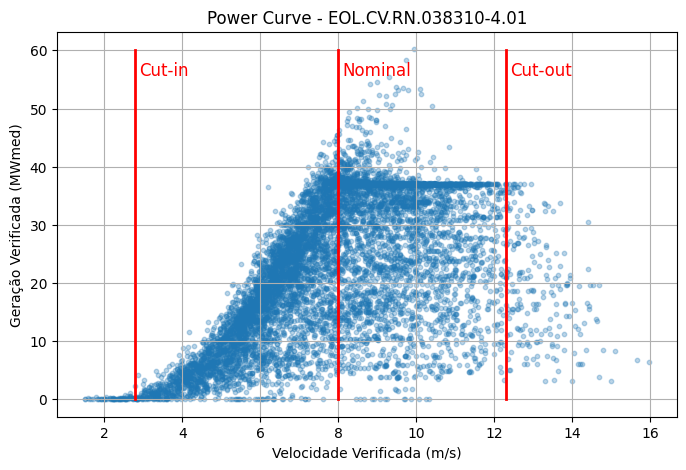

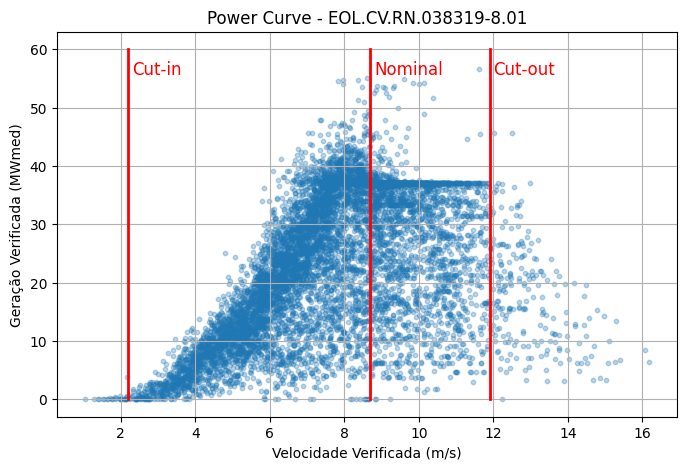

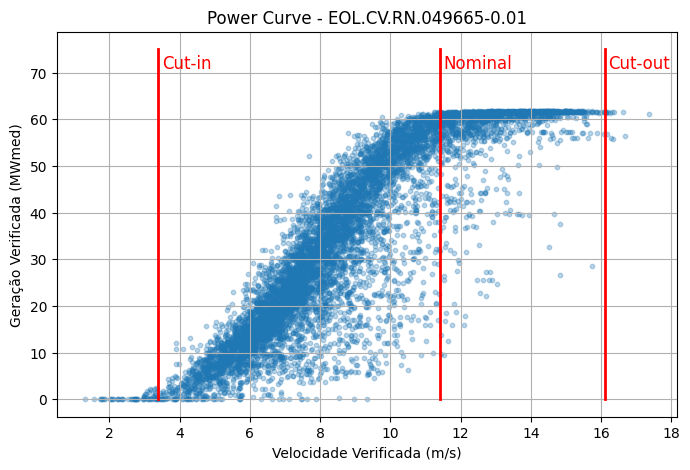

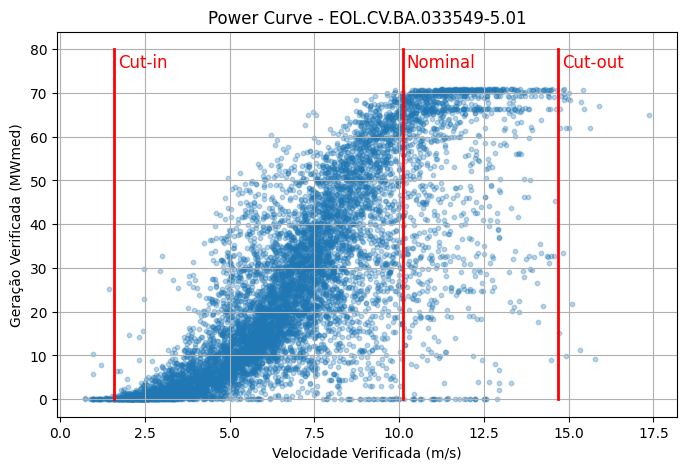

Text(7.5, -10, 'Região de possível desligamento')

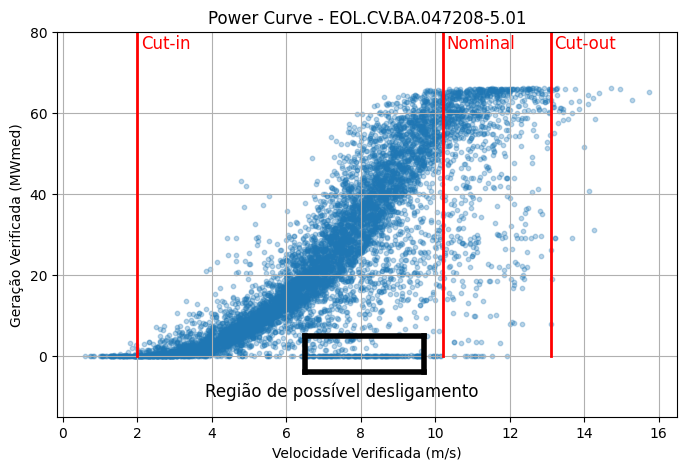

In [18]:
# Curva de potência típica de turbina eólica EOL.CV.RN.038310-4.01
plot_power_curve_by_ceg(
    df=final_df_ceg, # Para qualquer projeto que NÃO faça parte da CdV usar o dataset b
    ceg_list=["EOL.CV.RN.038310-4.01"]
)

val_pot_verif = np.array([2.8, 8.0, 12.3]) # Velocidades típicas de cut-in, nominal e cut-out para turbinas eólicas

for i in range(len(val_pot_verif)):
    plt.plot([val_pot_verif[i], val_pot_verif[i]], [0, 60], color="red", linestyle="-", linewidth=2)
    plt.text(val_pot_verif[i] + 0.1, 55, f"Cut-in" if i == 0 else "Nominal" if i == 1 else "Cut-out", color="red", fontsize=12, verticalalignment="bottom")

plt.show()

# Curva de potência típica de turbina eólica EOL.CV.RN.038319-8.01
plot_power_curve_by_ceg(
    df=final_df_ceg, # Para qualquer projeto que NÃO faça parte da CdV usar o dataset b
    ceg_list=["EOL.CV.RN.038319-8.01"]
)

val_pot_verif = np.array([2.2, 8.7, 11.9]) # Velocidades típicas de cut-in, nominal e cut-out para turbinas eólicas

for i in range(len(val_pot_verif)):
    plt.plot([val_pot_verif[i], val_pot_verif[i]], [0, 60], color="red", linestyle="-", linewidth=2)
    plt.text(val_pot_verif[i] + 0.1, 55, f"Cut-in" if i == 0 else "Nominal" if i == 1 else "Cut-out", color="red", fontsize=12, verticalalignment="bottom")

plt.show()


# Curva de potência típica de turbina eólica EOL.CV.RN.049665-0.01
plot_power_curve_by_ceg(
    df=final_df_ceg, # Para qualquer projeto que NÃO faça parte da CdV usar o dataset b
    ceg_list=["EOL.CV.RN.049665-0.01"]
)

val_pot_verif = np.array([3.4, 11.4, 16.1]) # Velocidades típicas de cut-in, nominal e cut-out para turbinas eólicas

for i in range(len(val_pot_verif)):
    plt.plot([val_pot_verif[i], val_pot_verif[i]], [0, 75], color="red", linestyle="-", linewidth=2)
    plt.text(val_pot_verif[i] + 0.1, 70, f"Cut-in" if i == 0 else "Nominal" if i == 1 else "Cut-out", color="red", fontsize=12, verticalalignment="bottom")

plt.show()


# Curva de potência típica de turbina eólica EOL.CV.BA.033549-5.01
plot_power_curve_by_ceg(
    df=final_df_ceg, # Para qualquer projeto que NÃO faça parte da CdV usar o dataset b
    ceg_list=["EOL.CV.BA.033549-5.01"]
)

val_pot_verif = np.array([1.6, 10.1, 14.7]) # Velocidades típicas de cut-in, nominal e cut-out para turbinas eólicas

for i in range(len(val_pot_verif)):
    plt.plot([val_pot_verif[i], val_pot_verif[i]], [0, 80], color="red", linestyle="-", linewidth=2)
    plt.text(val_pot_verif[i] + 0.1, 75, f"Cut-in" if i == 0 else "Nominal" if i == 1 else "Cut-out", color="red", fontsize=12, verticalalignment="bottom")

plt.show()


# Curva de potência típica de turbina eólica EOL.CV.BA.047208-5.01
plot_power_curve_by_ceg(
    df=final_df_ceg, # Para qualquer projeto que NÃO faça parte da CdV usar o dataset b
    ceg_list=["EOL.CV.BA.047208-5.01"]
)

val_pot_verif = np.array([2.0, 10.2, 13.1]) # Velocidades típicas de cut-in, nominal e cut-out para turbinas eólicas

for i in range(len(val_pot_verif)):
    plt.plot([val_pot_verif[i], val_pot_verif[i]], [0, 80], color="red", linestyle="-", linewidth=2)
    plt.text(val_pot_verif[i] + 0.1, 75, f"Cut-in" if i == 0 else "Nominal" if i == 1 else "Cut-out", color="red", fontsize=12, verticalalignment="bottom")

# desenhar um retângulo para destacar a região de operação típica entre cut-in e cut-out
plt.plot([6.5,6.5], [-4, 5], color="black", linestyle="-", linewidth=4)
plt.plot([9.7,9.7], [-4, 5], color="black", linestyle="-", linewidth=4)
plt.plot([6.5,9.7], [5, 5], color="black", linestyle="-", linewidth=4)
plt.plot([6.5,9.7], [-4, -4], color="black", linestyle="-", linewidth=4)

plt.ylim(-15, 80)

plt.text(7.5, -10, "Região de possível desligamento", color="black", fontsize=12, horizontalalignment="center")

### Insights sobre as curvas de potência

**1-** As cegs 038310-4 e 038319-8 do projeto RVD apresentaram a geração verificada nominal em aproximadamente 38 MW e maiores instabilidades (dispersão de pontos) para todo o espectro de velocidades estudado.

**2-** A ceg 49665-0 do prejo TGR apresentou cut-in apenas com ventos maiores que 3m/s, por outro lado, a potência nominal foi de 62 MW com janela de cerca de 4.5 em velocidade de vento.

**3-** A ceg 033549-5 do projeto BBS apresentou a meior potência nominal de cerca de 71 MW, no entanto, apresentou alta dispersão de pontos.

**4-** A curva de potência da ceg 047208-5 do projeto BBC indicou uma potência noominal em 67 MW porém em uma pequena janela de velocidade de vento (2.1m/s) chegando rapidamente ao ponto de cut-out. Essa ceg também apresentou uma região com alta densidade de pontos em 0 MW indicando um possível desligamento por outros meios.

**OBS** Visualizar os demais cegs pode ser feito através de final_df_ceg['ceg'].unique() em ceg_list



In [19]:
def prepare_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create temporal features for time-series analysis.
    """

    df = df.copy()

    df["din_instante"] = pd.to_datetime(
        df["din_instante"],
        errors="coerce"
    )

    df["date"] = df["din_instante"].dt.date

    df["year_month"] = (
        df["din_instante"]
        .dt.to_period("M")
        .astype(str)
    )

    df["hour"] = df["din_instante"].dt.hour

    return df


time_final_df_ceg = prepare_time_features(final_df_ceg)


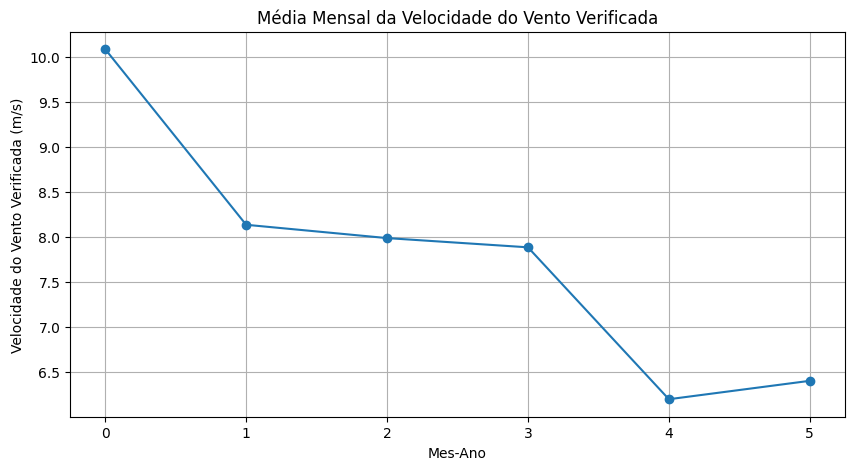

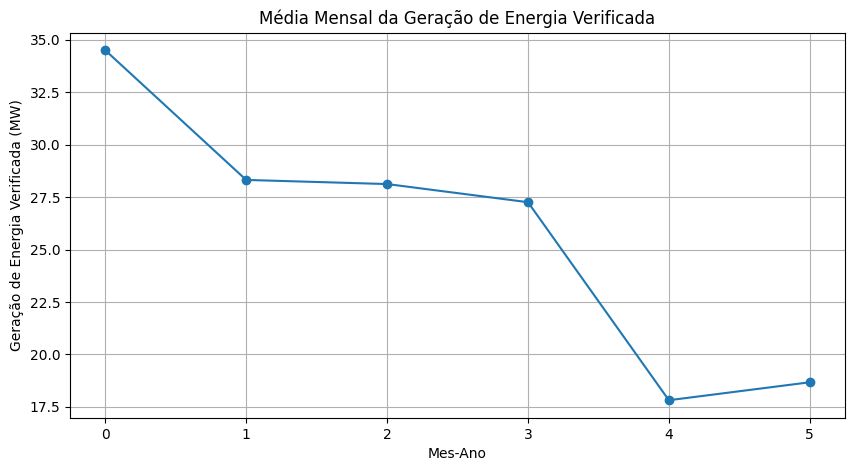

Estatísticas mensais da velocidade do vento verificada:
  year_month       mean  median       std    min     max
0    2025-10  10.088010  10.040  2.246609  0.436  19.710
1    2025-11   8.135204   8.220  2.398123  0.782  17.539
2    2025-12   7.987209   7.822  2.057109  0.858  17.356
3    2026-01   7.884536   7.867  2.397291  0.537  18.039
4    2026-02   6.194907   6.093  2.150062  0.544  15.763
5    2026-03   6.399641   6.459  2.018708  0.430  18.390
#######################################################
Estatísticas mensais da geração de energia verificada:
  year_month       mean  median        std  min     max
0    2025-10  34.505855  33.066  17.436681  0.0  70.981
1    2025-11  28.321668  27.092  18.239625  0.0  70.877
2    2025-12  28.124704  26.423  16.535115  0.0  70.911
3    2026-01  27.259095  25.694  17.506080  0.0  70.909
4    2026-02  17.817078  13.648  15.752045  0.0  70.995
5    2026-03  18.673018  15.995  15.018356  0.0  70.903


In [ ]:
# Variação da Média Mensal da Velocidade do Vento Verificada e da Média Mensal da Geração de Energia Verificada pelos meses

monthly_wind_stats = (
    time_final_df_ceg
    .groupby("year_month")["val_ventoverificado"]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .reset_index()
)

monthly_generation_stats = (
    time_final_df_ceg
    .groupby("year_month")["val_geracaoverificada"]
    .agg([
        "mean",
        "median",
        "std",
        "min", # Valor de desligamento costuma ser zero mesmo
        "max"
    ])
    .reset_index()
)

plt.figure(figsize=(10, 5))
monthly_wind_stats["mean"].plot(marker="o")
plt.title("Média Mensal da Velocidade do Vento Verificada")
plt.xlabel("Mes-Ano")
plt.ylabel("Velocidade do Vento Verificada (m/s)")
plt.grid(True)
plt.show() # O mês 0 corresponde a outubro de 2025, e o mês 5 corresponde a março de 2026, cobrindo o período de 6 meses disponível nos dados.

plt.figure(figsize=(10, 5))
monthly_generation_stats["mean"].plot(marker="o")
plt.title("Média Mensal da Geração de Energia Verificada")
plt.xlabel("Mes-Ano")
plt.ylabel("Geração de Energia Verificada (MW)")
plt.grid(True)
plt.show() # O mês 0 corresponde a outubro de 2025, e o mês 5 corresponde a março de 2026, cobrindo o período de 6 meses disponível nos dados.


print("Estatísticas mensais da velocidade do vento verificada:")
print(monthly_wind_stats)
print("#######################################################")
print("Estatísticas mensais da geração de energia verificada:")
print(monthly_generation_stats)

### Médias mensais de Geração e Velocidade de Vento

Em valores médios observa-se um comportamento semelhante entre essas duas grandezas. 

Durante o mes 10/2025 observou-se uma grande incidência de vento e consequentemente potência. Posteriormente, entre 11/2025 e 01/2026 os valores se mostraram muito próximos. Houve então uma forte queda em 02/2025 com permanência em 03/2025.

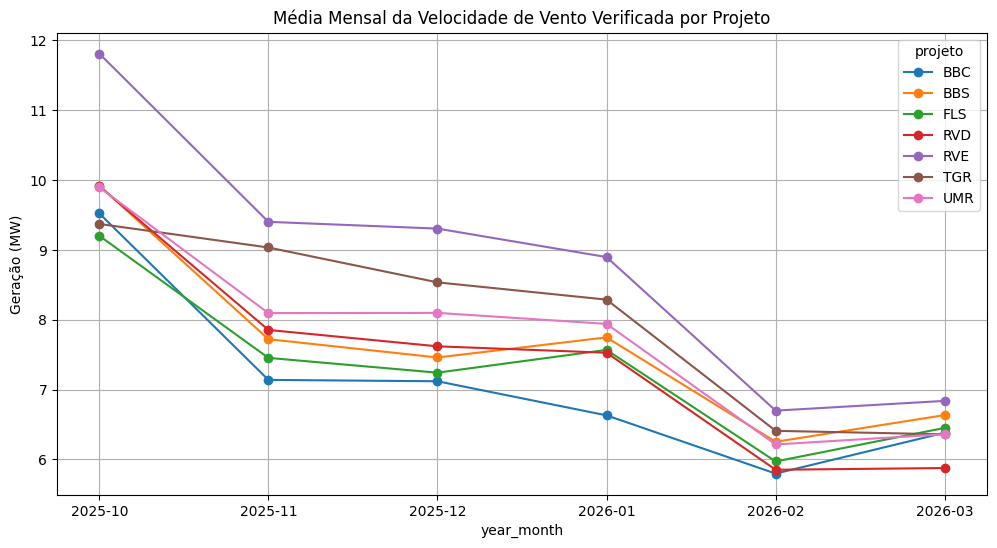

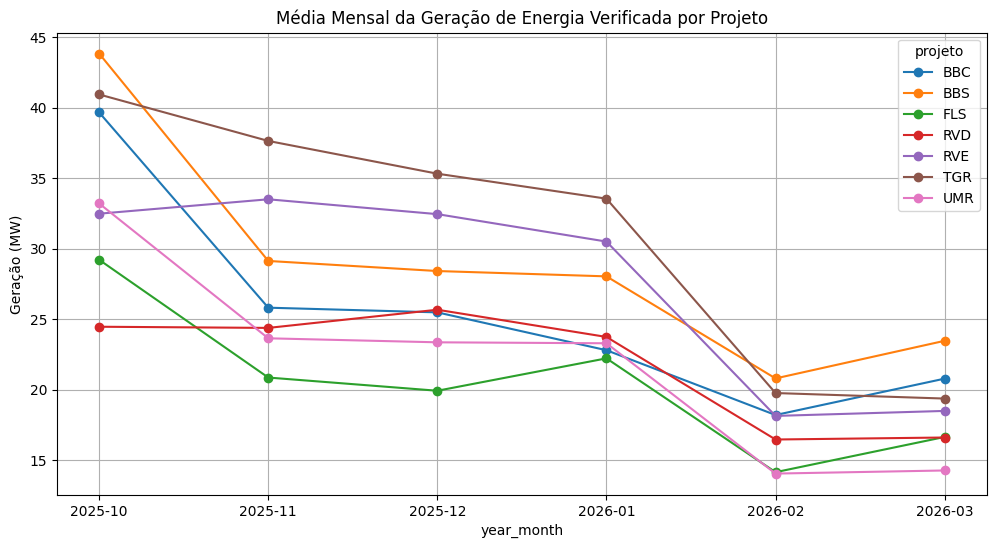

In [ ]:
# Variação da Média Mensal da Velocidade do Vento Verificada e da Média Mensal da Geração de Energia Verificada pelos meses por projeto

monthly_project_generation = (
    time_final_df_ceg
    .groupby(
        ["year_month", "projeto"]
    )["val_ventoverificado"]
    .mean()
    .unstack()
)

monthly_project_generation.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("Média Mensal da Velocidade de Vento Verificada por Projeto")
plt.ylabel("Geração (MW)")
plt.grid(True)
plt.show()


monthly_project_generation = (
    time_final_df_ceg
    .groupby(
        ["year_month", "projeto"]
    )["val_geracaoverificada"]
    .mean()
    .unstack()
)

monthly_project_generation.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("Média Mensal da Geração de Energia Verificada por Projeto")
plt.ylabel("Geração (MW)")
plt.grid(True)

plt.show()

### Médias mensais de Geração e Velocidade de Vento por projeto

Projetos | Estado

BBC |     BA 

BBS  |    BA

FLS  |    BA

RVD  |    RN

RVE   |   RN

TGR  |    RN

UMR  |    RN

A partir dos valores médios mensais de Potência verificada verifica-se que todos os projetos seguem comportamentos semelhantes justificando os valores médios. Então há sasonalidade entre os meses avaliados mas não há fortes influência geográficas (além das amplitudes).

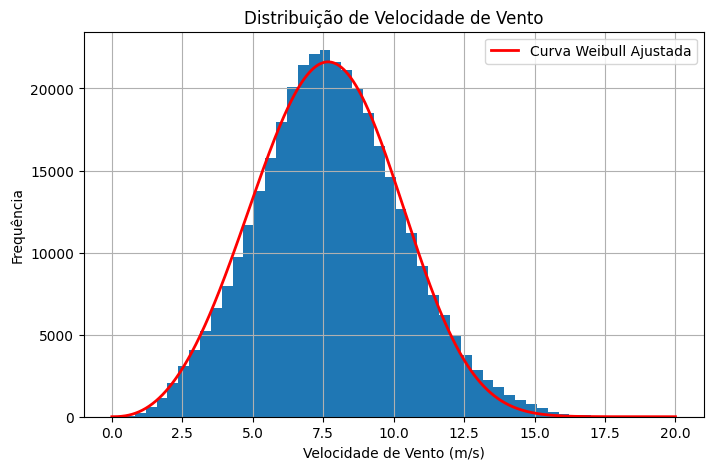

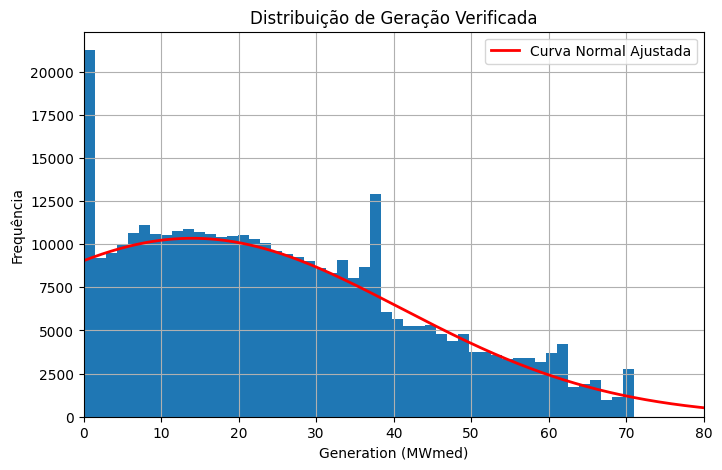

In [ ]:
# Frequência de Velocidade de Vento e Geração Verificada

plt.figure(figsize=(8, 5))

time_final_df_ceg["val_ventoverificado"].hist(
    bins=50
)
plt.title("Distribuição de Velocidade de Vento")
plt.xlabel("Velocidade de Vento (m/s)")
plt.ylabel("Frequência")


x = np.linspace(0, 20, 1000)
plt.plot(x, weibull_min.pdf(x, c=3.4, scale=8.5)* 140000, linewidth=2, color="red", label="Curva Weibull Ajustada") 
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

time_final_df_ceg["val_geracaoverificada"].hist(
    bins=50
)

plt.title("Distribuição de Geração Verificada")
plt.xlabel("Generation (MWmed)")
plt.ylabel("Frequência")
plt.xlim(0, 80)

x = np.linspace(0, 80, 1000)
plt.plot(x, norm.pdf(x, loc=14, scale=27) * 700000 , linewidth=2, color="red", label="Curva Normal Ajustada") 
plt.legend()
plt.show()

### Frequência de Velocidade de Vento e Geração Verificada, Livro Energia Eólica - Fadigas (2011)

Pelo gráfico de Velocidade de Vento observa-se que o pico ocorre entre $7$ e $8 m/s$, indicando as velocidades mais frequentes, já velocidades maiores que $16 m/s$ foram pouco frequêntes.

Pelo gráfico de Geração Verificada observa-se que a maior concentração dos valores ocorre entre $10$ e $20 , MWmed$, indicando as faixas de geração mais frequentes, enquanto valores acima de $60 , MWmed$ ocorreram com menor frequência.


A distribuição de frequências da Velocidade de Vento e Geração Verificada seguem distribuições bem comportadas. 
A Velocidade de Vento possui poucos valores extremos e segue adequadamente uma distribuição de Weibull, característica comum em séries de dados eólicos. 
Já a Geração Verificada apresenta uma distribuição mais próxima da Normal, com maior concentração de valores em torno da média e redução gradual das frequências para valores mais elevados.

## Modelagem de sistemas 

In [ ]:
# feature "restricao_ativa" que indica se há alguma restrição ativa (1) ou não (0) com base na presença de valores não nulos nas colunas de restrição

final_df_ceg["restricao_ativa"] = final_df_ceg.apply(
    lambda row: 1 if pd.notna(row["cof_cod_razaorestricao"]) else 0,
    axis=1
)

In [ ]:
def classify_operating_condition(
    df: pd.DataFrame
) -> pd.DataFrame:
    
    """
    Classify operating condition using ONS restriction data.
    """

    df = df.copy()

    df["operation_status"] = "normal"

    restriction_mask = (df["cof_cod_razaorestricao"].notna())

    df.loc[restriction_mask,"operation_status"] = "restricted"

    return df


def classify_operation_with_clustering(
    df: pd.DataFrame,
    wind_col: str = "val_ventoverificado",
    generation_col: str = "val_geracaoverificada",
    eps: float = 0.125
) -> pd.DataFrame:
    
    """
    Classify operating conditions using DBSCAN clustering.
    """

    df = df.copy()

    # n_max = len(df_max) = 8400 -> 50
    # Less samples would lead to too many clusters, hence min_samples = len(df)*50/8400
    min_samples = int(len(df) * 50 / 9000)

    clustering_df = df[[wind_col, generation_col]].dropna()


    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(clustering_df)

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
    )

    clusters = dbscan.fit_predict(X_scaled)

    clustering_df["cluster"] = clusters

    df.loc[clustering_df.index,"cluster"] = clustering_df["cluster"]

    return df


def plot_clustered_power_curve(
    df: pd.DataFrame,
    ceg: str
) -> None:
    
    """
    Plot clustered wind vs generation scatter
    with restriction type visualization.
    """

    plot_df = df[
        df["ceg"] == ceg
    ].copy()

    plt.figure(figsize=(10, 6))

    # Scatter principal colorido por cluster
    scatter = plt.scatter(
        plot_df["val_ventoverificado"],
        plot_df["val_geracaoverificada"],
        c=plot_df["cluster"],
        alpha=0.25,
        s=10
    )

    # Mapeamento dos tipos de restrição
    restriction_markers = {
        "REL": "x",
        "CNF": "^",
        "ENE": "s",
        "PAR": "D"
    }

    restriction_labels = {
        "REL": "REL",
        "CNF": "CNF",
        "ENE": "ENE",
        "PAR": "PAR"
    }

    # Plotar restrições separadamente
    for restriction_code, marker in restriction_markers.items():

        restriction_df = plot_df[
            plot_df["cof_cod_razaorestricao"] == restriction_code
        ]

        plt.scatter(
            restriction_df["val_ventoverificado"],
            restriction_df["val_geracaoverificada"],
            alpha=0.2,
            s=10,
            marker=marker,
            label=restriction_labels[restriction_code]
        )

    plt.title(f"DBSCAN Clustering - {ceg}")

    plt.xlabel("Velocidade do Vento (m/s)")
    plt.ylabel("Geração Verificada (MWmed)")

    plt.grid(True)

    plt.colorbar(
        scatter,
        label="Cluster"
    )

    plt.legend()

    plt.show()


def apply_clustering_per_ceg(
    df: pd.DataFrame
) -> pd.DataFrame:

    processed_dfs = []

    for _, group in df.groupby("ceg"):

        clustered_group = classify_operation_with_clustering(group)
        processed_dfs.append(clustered_group)

    return pd.concat(processed_dfs)

final_df_ceg_clustered = apply_clustering_per_ceg(final_df_ceg)

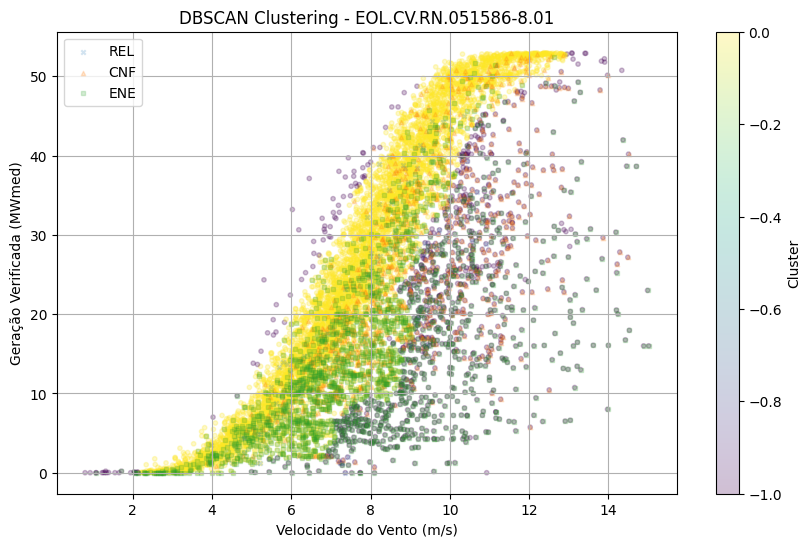

In [25]:
plot_clustered_power_curve(
    df=final_df_ceg_clustered,
    ceg="EOL.CV.RN.051586-8.01"
)

In [ ]:
# Filtrando para manter apenas os registros sem restrição ativa e pertencentes ao cluster majoritário

final_df_ceg_clustered_filtered = final_df_ceg_clustered[(final_df_ceg_clustered["restricao_ativa"] == 0) & (final_df_ceg_clustered["cluster"] == final_df_ceg_clustered["cluster"].value_counts().idxmax())].copy()

### Modelo preditivo

In [ ]:
#modelo de regressão por MLP para prever geração a partir da velocidade do vento, usando os dados filtrados (sem restrição ativa e sem outliers)
warnings.filterwarnings("ignore")

def prepare_training_data(
    df: pd.DataFrame,
    ceg: str
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
    
    # Preparar os dados de treinamento
    X_train, X_test, y_train, y_test = train_test_split(
        df[df["ceg"] == ceg][["val_ventoverificado"]].values,
        df[df["ceg"] == ceg]["val_geracaoverificada"].values,
        test_size=0.2,
        random_state=42
    )

    # Os dados possuem valores diferentes para o input e output, alem disso, em testes o MSE ficou em 22.92. Portanto, farei a normalização dos dados.
    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # O StandardScaler é mais apropriado para a variável de geração, pois ela pode ter uma distribuição mais próxima da normal,
                                # além disso, péssimos resultados foram obtidos com o MinMaxScaler.

    X_train = scaler_X.fit_transform(X_train)
    y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    X_test = scaler_X.transform(X_test)
    y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

    return X_train, X_test, y_train, y_test, scaler_X, scaler_y

def mlp_model_ceg_prediction(
    X_train: np.ndarray,
    y_train: np.ndarray,
    architectures: list[tuple[int]] = [(10, 10, 10, 25)],
    activation: str = "logistic",
    solver: str = "adam",
    max_iter: int = 2000
) -> None:
    """
    Train MLP regression model to predict generation from wind speed for a specific CEG.
    """

    # Treinar o modelo de MLP
    mlp = MLPRegressor(
        hidden_layer_sizes=architectures[0],
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    return mlp

def ploting_ceg_prediction(
    df: pd.DataFrame,
    ceg: str,
    model,
    scaler_X,
    scaler_y
) -> None:

    _, X_test, _, y_test, _, _ = prepare_training_data(
        df=df,
        ceg=ceg
    )

    y_pred_scaled = model.predict(X_test)

    X_test_real = scaler_X.inverse_transform(X_test).ravel()
    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    plt.figure(figsize=(8, 5))
    plt.scatter(X_test_real, y_test_real, color="green", label="Real", alpha=0.5, s=5)
    plt.scatter(X_test_real, y_pred_real, color="red", label="Previsto", alpha=0.5)

    plt.title(f"Curva de Potência - Real vs Previsto - {ceg}")
    plt.xlabel("Velocidade do Vento (m/s)")
    plt.ylabel("Geração Verificada (MWmed)")
    plt.legend()
    plt.grid(True)
    plt.show()

def predict_potential_generation(
    df: pd.DataFrame,
    ceg: str,
    model,
    scaler_X,
    scaler_y,
    plot = True                                 
):
    x = df[df["ceg"] == ceg][["val_ventoverificado"]].values

    x_scaled = scaler_X.transform(x)

    y_scaled = model.predict(x_scaled)

    y = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

    if plot:
        plt.figure(figsize=(8, 5))
        plt.scatter(
            df[df["ceg"] == ceg]["val_ventoverificado"],
            df[df["ceg"] == ceg]["val_geracaoverificada"],
            color="green",
            label="Real",
            alpha=0.3,
            s = 5
        )
        plt.scatter(
            df[df["ceg"] == ceg]["val_ventoverificado"],
            y,
            color="red",
            label="Previsto",
            alpha=0.3
        )
        plt.title(f"Curva de Potência da ceg {ceg}- Real vs Previsto")
        plt.xlabel("Velocidade do Vento (m/s)")
        plt.ylabel("Geração Verificada / Prevista (MW)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return y, y - df[df["ceg"] == ceg]["val_geracaoverificada"].values


In [ ]:
# Treinamento dos modelos preditivos

models_by_ceg = {}

final_df_ceg["val_geracao_predita"] = np.nan

for ceg, df_ceg_train in final_df_ceg_clustered_filtered.groupby("ceg"):

    if len(df_ceg_train) < 10:
        continue

    X_train, X_test, y_train, y_test, scaler_X, scaler_y = prepare_training_data(
        df=final_df_ceg_clustered_filtered,
        ceg=ceg
    )

    mlp = mlp_model_ceg_prediction(
        X_train=X_train,
        y_train=y_train
    )

    y_pred_scaled = mlp.predict(X_test)

    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)

    print(f"RMSE: {rmse:.2f} - CEG: {ceg}")
    print(f"R²: {r2:.2f} - CEG: {ceg}")

    models_by_ceg[ceg] = {
        "model": mlp,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y
    }

    mask = final_df_ceg["ceg"] == ceg

    pot_gen, diff_pot_gen = predict_potential_generation(
        df=final_df_ceg,
        ceg=ceg,
        model=mlp,
        scaler_X=scaler_X,
        scaler_y=scaler_y,
        plot=False
    )

    final_df_ceg.loc[mask, "val_geracao_predita"] = pot_gen

RMSE: 4.47 - CEG: EOL.CV.BA.032642-9.01
R²: 0.96 - CEG: EOL.CV.BA.032642-9.01
RMSE: 6.97 - CEG: EOL.CV.BA.033547-9.01
R²: 0.91 - CEG: EOL.CV.BA.033547-9.01
RMSE: 5.00 - CEG: EOL.CV.BA.033548-7.01
R²: 0.96 - CEG: EOL.CV.BA.033548-7.01
RMSE: 6.15 - CEG: EOL.CV.BA.033549-5.01
R²: 0.93 - CEG: EOL.CV.BA.033549-5.01
RMSE: 5.75 - CEG: EOL.CV.BA.037101-7.01
R²: 0.94 - CEG: EOL.CV.BA.037101-7.01
RMSE: 3.41 - CEG: EOL.CV.BA.037102-5.01
R²: 0.95 - CEG: EOL.CV.BA.037102-5.01
RMSE: 3.79 - CEG: EOL.CV.BA.037103-3.01
R²: 0.95 - CEG: EOL.CV.BA.037103-3.01
RMSE: 2.87 - CEG: EOL.CV.BA.037104-1.01
R²: 0.97 - CEG: EOL.CV.BA.037104-1.01
RMSE: 4.67 - CEG: EOL.CV.BA.047208-5.01
R²: 0.95 - CEG: EOL.CV.BA.047208-5.01
RMSE: 5.32 - CEG: EOL.CV.BA.051588-4.01
R²: 0.94 - CEG: EOL.CV.BA.051588-4.01
RMSE: 7.22 - CEG: EOL.CV.BA.051589-2.01
R²: 0.91 - CEG: EOL.CV.BA.051589-2.01
RMSE: 4.73 - CEG: EOL.CV.BA.051590-6.01
R²: 0.96 - CEG: EOL.CV.BA.051590-6.01
RMSE: 5.87 - CEG: EOL.CV.BA.051592-2.01
R²: 0.93 - CEG: EOL.CV.B

### Análise das métricas de modelo 

Dos $46$ modelos estudados apenas $1$ não apresentou bons resultados de $R^2$ e $RMSE$ (EOL.CV.RN.040625-2.01) apesar da automação de cluster. 
Mesmo com baixos resultados de $R^2$ e $RMSE$, modelo ainda mostrou formato semelhante ao apresentado na coluna "val_geracaoestimada". Os baixos valores ocorreram provavelmente por multiplos clusters na ceg.
Isso mostra que ambos os modelos (cluster e MLP) se mostraram eficientes para predizer a geração.

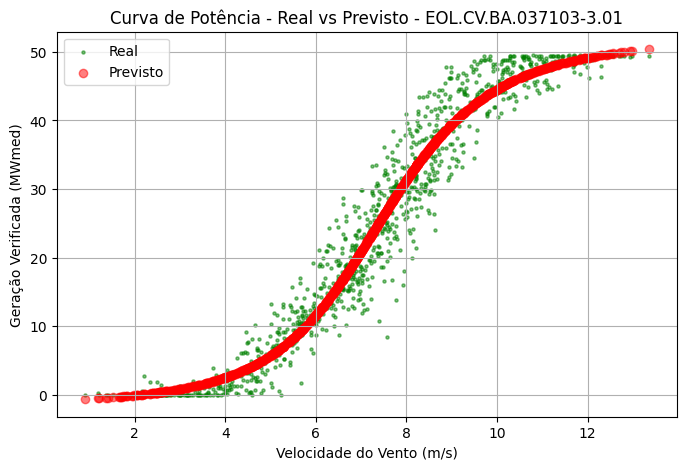

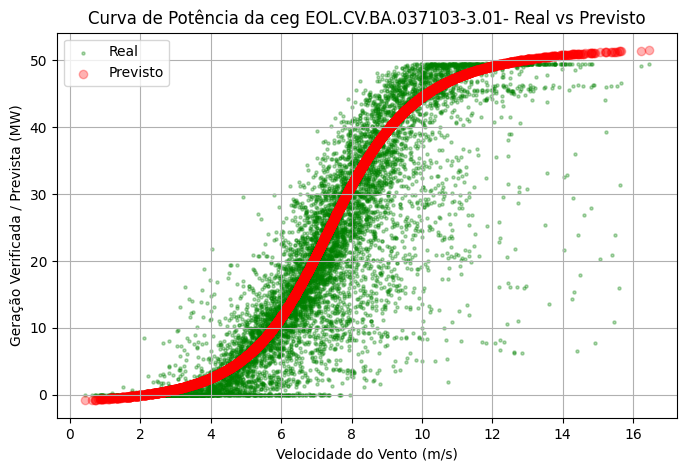

Diferênça média entre potência real e predita pelo modelo: 2.569662291946633 MW (a cada 30 minutos)
Diferênça total entre potência real e predita pelo modelo: 21608.29021297924 MW
Perda total de energia devido COFF: 10804.14510648962 MWh


In [29]:
#Exemplo de análise para um CEG específico
ceg = "EOL.CV.BA.037103-3.01"

ploting_ceg_prediction(
    df=final_df_ceg_clustered_filtered,
    ceg=ceg,
    model=models_by_ceg[ceg]["model"],
    scaler_X=models_by_ceg[ceg]["scaler_X"],
    scaler_y=models_by_ceg[ceg]["scaler_y"]
)

predict_potential_generation(
    df=final_df_ceg,
    ceg=ceg,
    model=models_by_ceg[ceg]["model"],
    scaler_X=models_by_ceg[ceg]["scaler_X"],
    scaler_y=models_by_ceg[ceg]["scaler_y"]
)

print(f"Diferênça média entre potência real e predita pelo modelo: {np.mean(final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracao_predita'] - final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracaoverificada'])} MW (a cada 30 minutos)")
print(f"Diferênça total entre potência real e predita pelo modelo: {np.sum(final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracao_predita'] - final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracaoverificada'])} MW")
print(f"Perda total de energia devido COFF: {np.sum(final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracao_predita'] - final_df_ceg[final_df_ceg['ceg'] == ceg]['val_geracaoverificada'])*0.5} MWh")

Text(0.5, 1.0, 'ceg EOL.CV.RN.047205-0.02')

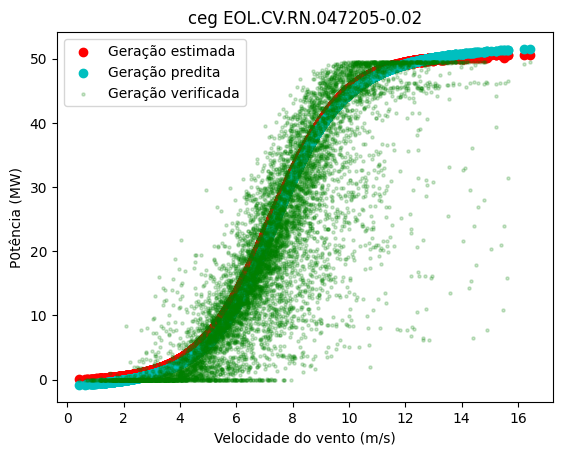

In [30]:
#Comparação da geraçã estimada e a geração predita pelo modelo.

plt.scatter(final_df_ceg[final_df_ceg["ceg"] == ceg][["val_ventoverificado"]],final_df_ceg[final_df_ceg["ceg"] == ceg][[ "val_geracaoestimada"]], label = "Geração estimada", color = "red")
plt.scatter(final_df_ceg[final_df_ceg["ceg"] == ceg][["val_ventoverificado"]],final_df_ceg[final_df_ceg["ceg"] == ceg][[ "val_geracao_predita"]], label = "Geração predita", color = "c")
plt.scatter(final_df_ceg[final_df_ceg["ceg"] == ceg][["val_ventoverificado"]],final_df_ceg[final_df_ceg["ceg"] == ceg][[ "val_geracaoverificada"]], alpha = 0.2, label = "Geração verificada", s = 5, color = "g")
plt.legend()
plt.xlabel("Velocidade do vento (m/s)")
plt.ylabel("P0tência (MW)")
plt.title("ceg EOL.CV.RN.047205-0.02")

In [ ]:
# Valores totais de perdas por COFF para diferentes restrições (aplicação pelo exemplo)

mid_final_df_ceg =  final_df_ceg[final_df_ceg["ceg"] == ceg][["val_geracaoverificada", "val_geracao_predita", "cof_cod_razaorestricao", "val_geracaoestimada"]]

for restriction_code in mid_final_df_ceg["cof_cod_razaorestricao"].dropna().unique():

    restriction_df = mid_final_df_ceg[mid_final_df_ceg["cof_cod_razaorestricao"] == restriction_code]

    diff_pot_gen_restriction = (restriction_df["val_geracao_predita"] - restriction_df["val_geracaoverificada"])

    print(f"Diferença total para restrição {restriction_code}: {np.sum(diff_pot_gen_restriction):.3f} MW ------ (% em relação ao total: {np.sum(diff_pot_gen_restriction)/np.sum(diff_pot_gen):.3f})")

Diferença total para restrição CNF: 6612.994 MW ------ (% em relação ao total: 0.203)
Diferença total para restrição ENE: 16657.629 MW ------ (% em relação ao total: 0.512)
Diferença total para restrição REL: 86.245 MW ------ (% em relação ao total: 0.003)


##  Cálculo de Perdas

Text(0, 0.5, 'val_geracaoverificada')

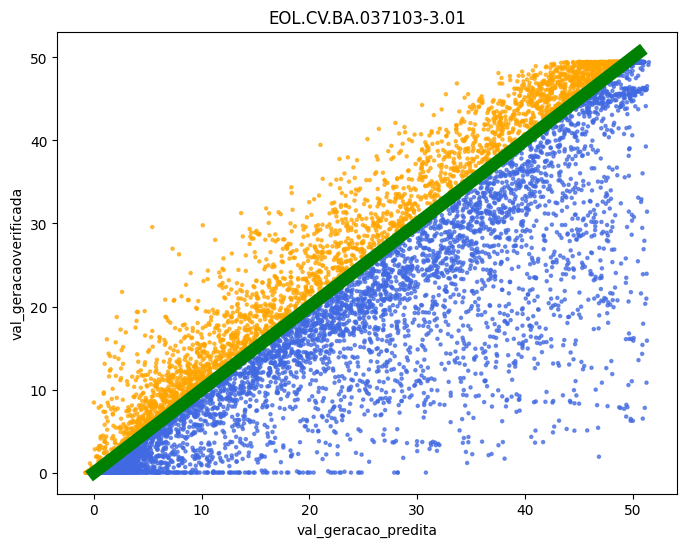

In [ ]:
# Geração real vs. geração potencial

predito = final_df_ceg[final_df_ceg["ceg"] == ceg]["val_geracao_predita"]
verificado = final_df_ceg[final_df_ceg["ceg"] == ceg]["val_geracaoverificada"]

# Definição de paleta de cores
cores = np.where(predito > verificado, "royalblue", "orange")

plt.figure(figsize=(8, 6))

plt.scatter(predito, verificado, c=cores, alpha=0.7, s = 5)

l = np.linspace(0,np.max(mid_final_df_ceg["val_geracaoestimada"]),1000)
plt.plot(l,l, color = "green",linewidth=9)
plt.title(f"{ceg}")
plt.xlabel("val_geracao_predita")
plt.ylabel("val_geracaoverificada")

In [ ]:
# Disponibilidade Energética

final_df_ceg["disp_energetica"] = np.nan

for ceg in final_df_ceg["ceg"].unique():

    ceg_df = final_df_ceg[final_df_ceg["ceg"] == ceg]

    disp_energ = (sum(ceg_df["val_geracaoverificada"]) / sum(ceg_df["val_geracao_predita"]))

    final_df_ceg.loc[final_df_ceg["ceg"] == ceg,"disp_energetica"] = disp_energ


### Fator de capacidade, Livro Energia Eólica - Fadigas (2011)

O Fator de Capacidade de uma usina geradora de energia é a razão entre a potência gerada e a potência instalada. Segundo o livro de Fadigas (2011) a potência considerada no projeto de uma usina eólica é a potência nominal do aerogerador. Sendo assim, basta usar o valor da poência nominal encontrada por uma SPEs e comparar com a potência entregue.

$ FC = \frac{P_{verificada}}{P_{instalada}} = \frac{P_{verificada}}{\underset{P \in Model}{\max} P_{nominal}}$

In [35]:
# Fator de Capacidade por CEG

final_df_ceg["capacity_factor"] = np.nan

for ceg in final_df_ceg["ceg"].unique():

    ceg_df = final_df_ceg[final_df_ceg["ceg"] == ceg]

    p_nominal = max(ceg_df["val_geracao_predita"])

    capacity_factor_value = (np.mean(ceg_df["val_geracaoverificada"]) / p_nominal)

    final_df_ceg.loc[final_df_ceg["ceg"] == ceg,"capacity_factor"] = capacity_factor_value

In [ ]:
# Perdas totais por COFF

final_df_ceg["perc_loss_coff"] = np.nan

for ceg in final_df_ceg["ceg"].unique():

    ceg_df = final_df_ceg[final_df_ceg["ceg"] == ceg]

    total_loss = ((ceg_df["val_geracao_predita"]- ceg_df["val_geracaoverificada"]).clip(lower=0).sum())

    total_potential = (ceg_df["val_geracao_predita"].sum())

    if total_potential > 0:

        perc_loss = (total_loss/ total_potential)

    else:

        perc_loss = np.nan

    final_df_ceg.loc[final_df_ceg["ceg"] == ceg,"perc_loss_coff"] = perc_loss

In [36]:
# Variância da Velocidade do Vento verificada

final_df_ceg["wind_variance"] = np.nan

for ceg in final_df_ceg["ceg"].unique():

    ceg_df = final_df_ceg[final_df_ceg["ceg"] == ceg]

    wind_variance_value = (np.var(ceg_df["val_ventoverificado"]))

    final_df_ceg.loc[final_df_ceg["ceg"] == ceg,"wind_variance"] = wind_variance_value

### Janela Nominal

Estima o tamanho da janela de potência nominal a partir dos valores de Velocidade de Vento em que há pelo menos $threshold$% da potência máxima.

$R = \frac{\text{Janela }\geq P_{nominal}}{\text{Janela Total}}$

In [ ]:
# Janela de potência nominal por threshold

final_df_ceg["rated_power_window"] = np.nan

threshold = 0.90 

for ceg in final_df_ceg["ceg"].unique():

    ceg_df = final_df_ceg[final_df_ceg["ceg"] == ceg]

    p_nominal = (ceg_df["val_geracao_predita"].max())

    rated_power_window_value = (ceg_df["val_geracaoverificada"]>= threshold * p_nominal).mean()

    final_df_ceg.loc[final_df_ceg["ceg"] == ceg,"rated_power_window"] = rated_power_window_value

## Score de SPEs

Um score para diferentes SPEs pode ser construído a partir de métricas formuladas nesse projeto, como:

**1. Recurso eólico -** O quanto de vento uma SPE recebe, quanto maior o valor esperado de vento, melhor é a SPE. ($W_{i}$), $\alpha_{1} = 0.20$

**2. Disponibilidade energética -** O quanto da energia potencial que foi capturada, quanto mais energia capturada, melhor melhor é a SPE. ($A_{i}$), $\alpha_{2} = 0.25$

**3. Percentual de perdas por constrained-off -** Quanto de poencial foi perdido por COFF, quanto menos energia perdida, melhor é a SPE. ($1 - L_{i}$), $\alpha_{3} = 0.20$

**4. Fator de capacidade -** Quanto da potência nominal foi efetivamente usada para geração de energia, quanto mais, melhor é a SPE. ($FC_{i}$), $\alpha_{4} = 0.15$

**5. Variânca do vento -** Avalia a estabilidade do vento incidente, indicando a frequência de ventos menores que cut-in e maiores que cut-off além de indicar operações mais previsíveis. Quanto menor, melhor é a SPE. ($1 - V_{i}$), $\alpha_{5} = 0.10$

**6. janela de potência nominal -** Avalia o tempo em que a SPE consegue operar próximo da potência máxima. Quanto maior, melhor é a SPE. ($R_{i}$), $\alpha_{6} = 0.10$

**7. Variação da potência pela velocidade de vento -** Avalia o quão eficientemente a SPE converte "vento em potência", quanto maior melhor é a SPE. ($\frac{dP_{i}}{dW_{i}}$), **OBS:** Não houve tempo hábil para aplicar essa métrica. 

O Score para cada SPEs $i$ pode ser modelado de maneira simples por uma combinação linear entre as métricas formuladas em que $Score:  \mathbb{R} \to  \mathbb{R}$

$Score_{i} =  \alpha_{1}W_{i} + \alpha_{2}A_{i} + \alpha_{3}(1 - L_{i}) + \alpha_{4}FC_{i} + \alpha_{5}(1 - V_{i}) + \alpha_{6}(R_{i})$ para $\sum_{k = 1}^{6} \alpha_{k} = 1$

In [ ]:
# Cada métrica está aparece em ranges de valores diferentes, então para fazer uma soma é necessário que todas estejam na mesma ordem de grandeza, 
def min_max_normalize(series: pd.Series) -> pd.Series:
    """
    Normalizing the metrics created
    """

    series = pd.to_numeric(series, errors="coerce")

    min_value = series.min()
    max_value = series.max()

    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(np.nan, index=series.index)

    if max_value == min_value:
        return pd.Series(1.0, index=series.index)

    return (series - min_value) / (max_value - min_value)


def calculate_ceg_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate CEG score using existing columns in final dataframe.
    """

    # Remove possíveis colunas duplicadas
    df = df.loc[:, ~df.columns.duplicated()].copy()

    score_df = (
        df
        .groupby("ceg", as_index=False)
        .agg(
            projeto=("projeto", "first"),
            wind_resource=("val_ventoverificado", "mean"),
            energy_availability=("disp_energetica", "first"),
            coff_loss=("perc_loss_coff", "first"),
            capacity_factor=("capacity_factor", "first"),
            wind_variance=("wind_variance", "first"),
            rated_power_window=("rated_power_window", "first")
        )
    )

    score_df["wind_resource_score"] = min_max_normalize(score_df["wind_resource"])

    score_df["energy_availability_score"] = min_max_normalize(score_df["energy_availability"])

    score_df["coff_loss_score"] = (1 - min_max_normalize(score_df["coff_loss"]))

    score_df["capacity_factor_score"] = min_max_normalize(score_df["capacity_factor"])

    score_df["wind_stability_score"] = (1 - min_max_normalize(score_df["wind_variance"]))

    score_df["rated_power_window_score"] = min_max_normalize(score_df["rated_power_window"])

    weights = {
        "wind_resource_score": 0.20,
        "energy_availability_score": 0.25,
        "coff_loss_score": 0.20,
        "capacity_factor_score": 0.15,
        "wind_stability_score": 0.10,
        "rated_power_window_score": 0.10
    }

    score_df["ceg_score"] = sum(score_df[col] * weight for col, weight in weights.items()) * 100

    return score_df.sort_values(by="ceg_score",ascending=False).reset_index(drop=True)

In [47]:
ceg_score_df = calculate_ceg_score(final_df_ceg)

# Exibir os 10 CEGs com melhor pontuação

ceg_score_df.head(10)

,ceg,projeto,wind_resource,energy_availability,coff_loss,capacity_factor,wind_variance,rated_power_window,wind_resource_score,energy_availability_score,coff_loss_score,capacity_factor_score,wind_stability_score,rated_power_window_score,ceg_score
0,EOL.CV.RN.049665-0.01,TGR,8.835575,0.954058,0.095803,0.540162,7.338946,0.197487,0.932181,0.437299,1.000000,0.371122,0.417218,0.371977,63.034864
1,EOL.CV.RN.050016-0.01,TGR,5.587544,1.166650,0.129183,0.548587,2.769530,0.214100,0.000000,1.000000,0.786200,0.384910,1.000000,0.403269,60.530344
2,EOL.CV.RN.049667-7.01,TGR,7.901920,0.937219,0.111740,0.508684,4.343840,0.126044,0.664223,0.392726,0.897929,0.319612,0.799213,0.237411,56.221623
3,EOL.CV.RN.049664-2.01,TGR,8.421810,0.945603,0.119979,0.514885,6.484606,0.129313,0.813431,0.414918,0.845158,0.329759,0.526180,0.243568,56.188597
4,EOL.CV.RN.040625-2.01,RVD,7.977517,0.924623,0.251931,0.924465,4.490126,0.530912,0.685919,0.359385,0.000000,1.000000,0.780556,1.000000,55.508578
5,EOL.CV.RN.049666-9.01,TGR,7.987037,0.928998,0.116460,0.500413,4.376199,0.116736,0.688652,0.370966,0.867692,0.306077,0.795086,0.219878,55.141817
6,EOL.CV.RN.049668-5.01,TGR,7.882758,0.945594,0.109135,0.460527,4.138234,0.054233,0.658724,0.414895,0.914612,0.240806,0.825436,0.102150,54.727043
7,EOL.CV.RN.051585-0.01,UMR,7.240446,0.964458,0.170715,0.531994,4.526315,0.172045,0.474381,0.464825,0.520187,0.357756,0.775940,0.324056,47.878290
8,EOL.CV.RN.049669-3.01,TGR,7.134420,0.965427,0.160113,0.451632,3.434286,0.112647,0.443952,0.467389,0.588093,0.226252,0.915217,0.212175,46.993309
9,EOL.CV.RN.049671-5.01,TGR,7.199678,0.950914,0.149915,0.390759,3.708791,0.049466,0.462681,0.428976,0.653417,0.126638,0.880207,0.093172,44.679720


In [48]:
# Exibir os 10 CEGs com pior pontuação

(ceg_score_df.tail(10))


,ceg,projeto,wind_resource,energy_availability,coff_loss,capacity_factor,wind_variance,rated_power_window,wind_resource_score,energy_availability_score,coff_loss_score,capacity_factor_score,wind_stability_score,rated_power_window_score,ceg_score
36,EOL.CV.BA.051590-6.01,BBC,7.193961,0.854309,0.193629,0.378230,6.284887,0.067982,0.461040,0.173273,0.373422,0.106135,0.551652,0.128048,29.410102
37,EOL.CV.BA.051595-7.01,BBC,7.160267,0.853072,0.197642,0.391914,5.938394,0.058234,0.451370,0.170000,0.347718,0.128528,0.595844,0.109687,29.214993
38,EOL.CV.RN.033681-5.01,RVE,8.966789,0.796932,0.237331,0.416583,7.562029,0.048965,0.969839,0.021405,0.093514,0.168897,0.388766,0.092228,29.145576
39,EOL.CV.BA.033547-9.01,BBS,7.475957,0.857770,0.201717,0.377037,6.910338,0.041796,0.541972,0.182436,0.321618,0.104183,0.471883,0.078725,28.901506
40,EOL.CV.BA.051588-4.01,BBC,7.381041,0.858133,0.197582,0.337656,6.983723,0.035896,0.514732,0.183396,0.348105,0.039739,0.462523,0.067612,27.739080
41,EOL.CV.BA.051592-2.01,BBC,6.994811,0.862359,0.206773,0.382102,6.751218,0.084937,0.403884,0.194582,0.289236,0.112471,0.492177,0.159983,26.935635
42,EOL.CV.BA.051589-2.01,BBC,7.170526,0.843729,0.222483,0.382627,6.878714,0.092414,0.454314,0.145272,0.188611,0.113330,0.475916,0.174067,24.690073
43,EOL.CV.BA.033549-5.01,BBS,6.952214,0.871396,0.213318,0.352849,7.361682,0.040584,0.391659,0.218502,0.247315,0.064601,0.414318,0.076443,24.118647
44,EOL.CV.BA.051593-0.01,BBC,7.046401,0.844370,0.210332,0.313371,6.594041,0.000000,0.418690,0.146968,0.266440,0.000000,0.512223,0.000000,22.499038
45,EOL.CV.RN.034937-2.01,RVE,8.989619,NaN,NaN,NaN,7.806348,0.000000,0.976391,NaN,NaN,NaN,0.357606,0.000000,NaN
